# Week 4 - Job Listing Analyzer Agent

**Community Contribution by James Kimani**

A LangGraph agent that takes a job description and produces a comprehensive analysis:

| Node | Role |
|------|------|
| **Skill Extractor** | Pulls out required vs nice-to-have skills, experience level, and tech stack |
| **Company Researcher** | Uses Tavily web search to find company reviews, salary data, and culture info |
| **Red Flag Detector** | Spots vague language, unrealistic expectations, or concerning patterns |
| **Resume Advisor** | Generates tailored resume bullet points and a cover letter outline |
| **Salary Estimator** | Researches comparable roles and estimates a salary range |
| **Report Writer** | Compiles everything into a structured markdown report and saves it to disk |
| **Evaluator** | Reviews the final report for completeness before delivering it |

The graph uses conditional routing: if the evaluator finds gaps, it loops the report back to the writer with feedback. Each node is timed and logged so you can see exactly what's happening and how long each step takes.

In [4]:
from typing import Annotated, List, Any, Optional, Dict
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from IPython.display import Image, display, Markdown

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_tavily import TavilySearch

import gradio as gr
import uuid
import json
import os
import time
import operator

In [5]:
load_dotenv(override=True)
os.makedirs("sandbox", exist_ok=True)

## Step 1: Define the State

Unlike a generic chatbot, our state carries structured analysis fields that each node populates.
The `messages` list is still here for LangGraph compatibility, but the real work lives in the dedicated fields.

In [6]:
class SkillsAnalysis(BaseModel):
    required_skills: List[str] = Field(default_factory=list, description="Must-have skills")
    nice_to_have_skills: List[str] = Field(default_factory=list, description="Preferred but not required")
    experience_level: str = Field(default="", description="e.g. Junior, Mid, Senior, Lead")
    tech_stack: List[str] = Field(default_factory=list, description="Specific technologies mentioned")
    soft_skills: List[str] = Field(default_factory=list, description="Communication, leadership, etc.")


class RedFlags(BaseModel):
    flags: List[str] = Field(default_factory=list, description="Concerning patterns found")
    severity: str = Field(default="low", description="Overall severity: low / medium / high")
    positive_signals: List[str] = Field(default_factory=list, description="Good signs in the listing")


class ResumeAdvice(BaseModel):
    bullet_points: List[str] = Field(default_factory=list, description="Tailored resume bullets")
    cover_letter_outline: str = Field(default="", description="Cover letter structure")
    keywords_to_include: List[str] = Field(default_factory=list, description="ATS-friendly keywords")


class SalaryEstimate(BaseModel):
    low: int = Field(default=0, description="Low end of range (USD)")
    mid: int = Field(default=0, description="Midpoint (USD)")
    high: int = Field(default=0, description="High end of range (USD)")
    reasoning: str = Field(default="", description="How this was estimated")
    currency_note: str = Field(default="USD", description="Currency used")


class EvaluatorOutput(BaseModel):
    feedback: str = Field(description="What's missing or could be improved")
    is_complete: bool = Field(description="Whether the report is comprehensive enough")


class State(TypedDict):
    messages: Annotated[List[Any], add_messages]
    job_description: str
    skills_analysis: Optional[dict]
    red_flags: Optional[dict]
    resume_advice: Optional[dict]
    salary_estimate: Optional[dict]
    company_research: Optional[str]
    final_report: Optional[str]
    evaluator_feedback: Optional[str]
    is_complete: bool
    revision_count: int
    status_log: Annotated[List[str], operator.add]

## Step 2: Create the LLMs

Each analysis node gets its own structured output schema so we get clean, parseable results.

In [7]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.2)

skills_llm = llm.with_structured_output(SkillsAnalysis)
redflags_llm = llm.with_structured_output(RedFlags)
resume_llm = llm.with_structured_output(ResumeAdvice)
salary_llm = llm.with_structured_output(SalaryEstimate)
evaluator_llm = llm.with_structured_output(EvaluatorOutput)
writer_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.3)

try:
    tavily = TavilySearch(max_results=5)
    print("Tavily search: enabled")
except Exception as e:
    tavily = None
    print(f"Tavily search: disabled ({e})")
    print("Add TAVILY_API_KEY to your .env to enable company research via web search.")


def log_step(name: str, elapsed: float) -> str:
    return f"[{time.strftime('%H:%M:%S')}] {name} completed in {elapsed:.1f}s"

Tavily search: enabled


## Step 3: Define the Nodes

Each node is a focused analyst with a single responsibility.

In [8]:
def skill_extractor(state: State) -> Dict[str, Any]:
    """Extract skills, experience level, and tech stack from the job description."""
    t0 = time.time()
    result = skills_llm.invoke([
        SystemMessage(content="""You are an expert tech recruiter. Analyze the job description and extract:
- Required skills vs nice-to-have skills
- Experience level (Junior/Mid/Senior/Lead/Principal)
- Specific technologies and frameworks
- Soft skills mentioned
Be thorough - read between the lines for implicit requirements."""),
        HumanMessage(content=state["job_description"]),
    ])
    elapsed = time.time() - t0
    return {
        "skills_analysis": result.model_dump(),
        "status_log": [log_step("Skill Extractor", elapsed)],
    }


def company_researcher(state: State) -> Dict[str, Any]:
    """Use Tavily to search for company info, reviews, and reputation."""
    t0 = time.time()

    if tavily is None:
        elapsed = time.time() - t0
        return {
            "company_research": "Web search unavailable (no TAVILY_API_KEY). Add it to .env to enable.",
            "status_log": [log_step("Company Researcher (SKIPPED - no API key)", elapsed)],
        }

    jd = state["job_description"]
    company_hint = jd.split("\n")[0][:100]

    queries = [
        f"{company_hint} company reviews glassdoor",
        f"{company_hint} salary range compensation",
        f"{company_hint} company culture work life balance",
    ]

    all_results = []
    for q in queries:
        try:
            results = tavily.invoke(q)
            if isinstance(results, list):
                for r in results:
                    if isinstance(r, dict):
                        title = r.get("title", r.get("url", ""))
                        snippet = r.get("content", "")[:300]
                        url = r.get("url", "")
                        all_results.append(f"**{title}**\n{snippet}\n_Source: {url}_")
                    else:
                        all_results.append(str(r)[:300])
            elif isinstance(results, str):
                all_results.append(results[:500])
        except Exception as e:
            all_results.append(f"Search failed for '{q}': {e}")

    research = "\n\n---\n\n".join(all_results) if all_results else "No results found."
    elapsed = time.time() - t0
    return {
        "company_research": research,
        "status_log": [log_step(f"Company Researcher ({len(all_results)} results)", elapsed)],
    }


def red_flag_detector(state: State) -> Dict[str, Any]:
    """Identify red flags and positive signals in the listing."""
    t0 = time.time()
    result = redflags_llm.invoke([
        SystemMessage(content="""You are a career coach who helps job seekers spot problematic job listings.
Look for red flags such as:
- Vague responsibilities ("wear many hats", "fast-paced environment" used as excuse for overwork)
- Unrealistic combo of skills for the level (e.g. 10 years React for a junior role)
- No mention of salary, benefits, or growth
- "Unlimited PTO" or "we're like a family" without substance
- Requiring too many unrelated skills
- Signs of high turnover

Also note positive signals like clear growth paths, good benefits, reasonable expectations, inclusive language."""),
        HumanMessage(content=state["job_description"]),
    ])
    elapsed = time.time() - t0
    return {
        "red_flags": result.model_dump(),
        "status_log": [log_step("Red Flag Detector", elapsed)],
    }


def resume_advisor(state: State) -> Dict[str, Any]:
    """Generate tailored resume bullets and cover letter outline."""
    t0 = time.time()
    skills = json.dumps(state.get("skills_analysis", {}), indent=2)
    result = resume_llm.invoke([
        SystemMessage(content="""You are a professional resume writer and career strategist.
Based on the job description and extracted skills, generate:
1. 5-8 strong resume bullet points using the STAR method (Situation, Task, Action, Result)
   - Use action verbs and quantifiable results where possible
   - Tailor each bullet to match what this specific role needs
2. A cover letter outline with key talking points for each paragraph
3. ATS-friendly keywords the applicant should weave into their resume"""),
        HumanMessage(content=f"Job description:\n{state['job_description']}\n\nExtracted skills:\n{skills}"),
    ])
    elapsed = time.time() - t0
    return {
        "resume_advice": result.model_dump(),
        "status_log": [log_step("Resume Advisor", elapsed)],
    }


def salary_estimator(state: State) -> Dict[str, Any]:
    """Estimate salary range based on role, skills, and experience level."""
    t0 = time.time()
    skills = json.dumps(state.get("skills_analysis", {}), indent=2)
    result = salary_llm.invoke([
        SystemMessage(content="""You are a compensation analyst. Based on the job description and extracted skills,
estimate a salary range (low / mid / high) in USD.
Consider: experience level, tech stack demand, role scope, and typical market rates.
If the listing mentions a location, factor in cost-of-living. For remote roles, use US market averages.
Explain your reasoning."""),
        HumanMessage(content=f"Job description:\n{state['job_description']}\n\nExtracted skills:\n{skills}"),
    ])
    elapsed = time.time() - t0
    return {
        "salary_estimate": result.model_dump(),
        "status_log": [log_step("Salary Estimator", elapsed)],
    }

## Step 4: Report Writer & Evaluator

The writer compiles all analyses into a clean markdown report.
The evaluator reviews it and can send it back for revision if sections are weak.

In [9]:
def report_writer(state: State) -> Dict[str, Any]:
    """Compile all analyses into a structured markdown report."""
    t0 = time.time()
    context = f"""Compile a comprehensive Job Listing Analysis Report in markdown.

## Source Data

**Job Description:**
{state['job_description']}

**Skills Analysis:**
{json.dumps(state.get('skills_analysis', {}), indent=2)}

**Red Flags:**
{json.dumps(state.get('red_flags', {}), indent=2)}

**Resume Advice:**
{json.dumps(state.get('resume_advice', {}), indent=2)}

**Salary Estimate:**
{json.dumps(state.get('salary_estimate', {}), indent=2)}

**Company Research (from web search):**
{state.get('company_research', 'No research available')}"""

    if state.get("evaluator_feedback"):
        context += f"""\n\n**Evaluator Feedback (address these gaps):**
{state['evaluator_feedback']}"""

    result = writer_llm.invoke([
        SystemMessage(content="""You are a technical writer producing a Job Listing Analysis Report.
Structure it with these sections:
1. **Overview** - Role title, company, level, one-line verdict
2. **Skills Breakdown** - Table of required vs nice-to-have, tech stack
3. **Red Flags & Green Lights** - What to watch out for and what looks good
4. **Company Intel** - What web research revealed about the company (reviews, reputation, culture)
5. **Salary Estimate** - Range with reasoning, cross-referenced with web data if available
6. **Resume Strategy** - Tailored bullet points ready to paste
7. **Cover Letter Outline** - Paragraph-by-paragraph plan
8. **Verdict** - Overall assessment and recommendation (Apply / Proceed with caution / Skip)

Make it actionable and honest. Use markdown tables, bold, and bullet points for readability.
Include source URLs from the company research where relevant."""),
        HumanMessage(content=context),
    ])

    report = result.content

    filepath = "sandbox/job_analysis_report.md"
    with open(filepath, "w") as f:
        f.write(report)

    elapsed = time.time() - t0
    return {
        "final_report": report,
        "messages": [{"role": "assistant", "content": report}],
        "status_log": [log_step("Report Writer", elapsed)],
    }


def evaluator(state: State) -> Dict[str, Any]:
    """Check if the report is comprehensive enough to deliver."""
    t0 = time.time()
    result = evaluator_llm.invoke([
        SystemMessage(content="""You evaluate Job Listing Analysis Reports.
A complete report MUST have all of these:
- Skills breakdown with required vs nice-to-have
- At least 3 red flags or a clear statement that none were found
- Company research section with web-sourced insights
- Salary range with reasoning
- At least 5 resume bullet points
- A cover letter outline
- A clear verdict (Apply / Proceed with caution / Skip)

If anything is missing or shallow, mark as incomplete and specify what to fix."""),
        HumanMessage(content=f"Report to evaluate:\n\n{state.get('final_report', 'No report generated')}"),
    ])

    new_count = state.get("revision_count", 0) + 1
    elapsed = time.time() - t0
    verdict = "PASS" if result.is_complete else f"REVISE - {result.feedback[:80]}"

    return {
        "evaluator_feedback": result.feedback,
        "is_complete": result.is_complete,
        "revision_count": new_count,
        "status_log": [log_step(f"Evaluator (#{new_count}: {verdict})", elapsed)],
    }

## Step 5: Routing Logic

After evaluation, either deliver the report or send it back for revision (max 2 revisions to avoid infinite loops).

In [10]:
def evaluation_router(state: State) -> str:
    if state.get("is_complete", False) or state.get("revision_count", 0) >= 2:
        return "done"
    return "revise"

## Step 6: Build & Compile the Graph

The first four analysis nodes run in sequence (skill extractor feeds into the others),
then the report writer and evaluator form a revision loop.

In [11]:
memory = MemorySaver()
graph_builder = StateGraph(State)

graph_builder.add_node("skill_extractor", skill_extractor)
graph_builder.add_node("company_researcher", company_researcher)
graph_builder.add_node("red_flag_detector", red_flag_detector)
graph_builder.add_node("resume_advisor", resume_advisor)
graph_builder.add_node("salary_estimator", salary_estimator)
graph_builder.add_node("report_writer", report_writer)
graph_builder.add_node("evaluator", evaluator)

graph_builder.add_edge(START, "skill_extractor")
graph_builder.add_edge(START, "company_researcher")
graph_builder.add_edge("skill_extractor", "red_flag_detector")
graph_builder.add_edge("skill_extractor", "resume_advisor")
graph_builder.add_edge("skill_extractor", "salary_estimator")
graph_builder.add_edge("company_researcher", "report_writer")
graph_builder.add_edge("red_flag_detector", "report_writer")
graph_builder.add_edge("resume_advisor", "report_writer")
graph_builder.add_edge("salary_estimator", "report_writer")
graph_builder.add_edge("report_writer", "evaluator")
graph_builder.add_conditional_edges("evaluator", evaluation_router, {"revise": "report_writer", "done": END})

graph = graph_builder.compile(checkpointer=memory)

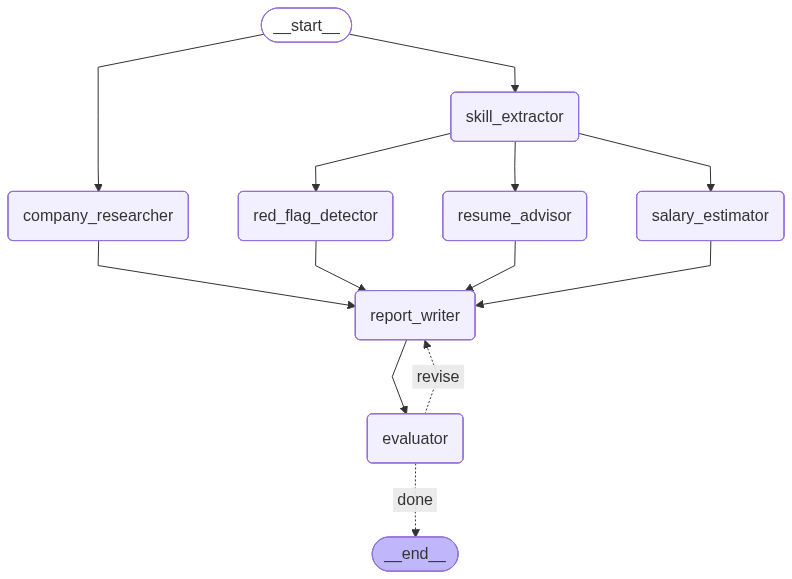

In [12]:
display(Image(graph.get_graph().draw_mermaid_png()))


PIPELINE LOG
  [13:36:58] Company Researcher (0 results) completed in 5.8s
  [13:36:59] Skill Extractor completed in 6.2s
  [13:37:03] Red Flag Detector completed in 4.1s
  [13:37:16] Report Writer completed in 17.2s
  [13:37:10] Resume Advisor completed in 11.1s
  [13:37:03] Salary Estimator completed in 4.2s
  [13:37:18] Evaluator (#1: REVISE - The report is comprehensive and covers all required sections thoroughly. However) completed in 2.3s
  [13:37:38] Report Writer completed in 22.2s
  [13:37:41] Evaluator (#2: REVISE - The report is mostly comprehensive but lacks a detailed company research section) completed in 2.5s
  [13:38:01] Report Writer completed in 22.6s
  [13:38:04] Evaluator (#3: REVISE - The report is mostly comprehensive but lacks a detailed company research section) completed in 3.2s
  [13:38:24] Report Writer completed in 23.4s
  [13:38:30] Evaluator (#4: REVISE - The report is mostly comprehensive, but it lacks a detailed company research sec) completed in 6.0s
 

# Job Listing Analysis Report

## 1. Overview
- **Role Title:** Senior Full-Stack Engineer
- **Company:** FinTech Startup (Remote)
- **Level:** Senior
- **One-Line Verdict:** Promising opportunity with a growing fintech startup, but potential red flags regarding expectations and transparency.

## 2. Skills Breakdown

| **Required Skills**                                         | **Nice-to-Have Skills**                          |
|-----------------------------------------------------------|-------------------------------------------------|
| 5+ years of professional software development experience   | Experience with mobile money integrations (M-Pesa, Airtel Money) |
| Strong proficiency in Python (FastAPI or Django)          | Contributions to open source projects           |
| Strong proficiency in TypeScript/React                     |                                                 |
| Experience with PostgreSQL                                  |                                                 |
| Experience with Redis                                       |                                                 |
| Experience with message queues (RabbitMQ/Kafka)           |                                                 |
| Familiarity with AWS (ECS, Lambda, S3, RDS)               |                                                 |
| Experience building and consuming RESTful APIs             |                                                 |
| Experience with GraphQL                                     |                                                 |
| Understanding of CI/CD pipelines                            |                                                 |
| Experience with containerization (Docker, Kubernetes)     |                                                 |

### Tech Stack
- **Languages & Frameworks:** Python, FastAPI, Django, TypeScript, React
- **Databases:** PostgreSQL, Redis
- **Message Queues:** RabbitMQ, Kafka
- **Cloud Services:** AWS (ECS, Lambda, S3, RDS)
- **APIs:** RESTful APIs, GraphQL
- **DevOps Tools:** Docker, Kubernetes

### Soft Skills
- Ability to thrive in ambiguity
- Adaptability
- Team player
- Strong work ethic

## 3. Red Flags & Green Lights

### Red Flags
- **Vague Responsibilities:** Phrases like "wear many hats" and "thrive in ambiguity" may indicate overwork or unclear expectations.
- **No Salary Range Provided:** Lack of transparency regarding compensation can be a concern.
- **Unlimited PTO:** Mentioned without details on implementation or potential limitations.
- **Extensive Required Skills:** The combination of required skills may indicate unrealistic expectations for a senior role.

### Green Lights
- **Competitive Salary Mentioned:** Indicates market awareness.
- **Equity Package Offered:** Good incentive for employees.
- **Positive Benefits:** Health insurance and home office stipend are attractive.
- **Team Culture Focus:** Annual team retreats suggest a strong emphasis on team bonding.

## 4. Company Intel
- **Company Reputation:** No specific reviews or insights found during web research.
- **Culture:** Described as family-oriented with a hard work and play ethos. However, the lack of detailed company insights raises concerns about transparency and employee satisfaction.

## 5. Salary Estimate
- **Estimated Salary Range:** $120,000 - $160,000
  - **Reasoning:** 
    - The salary for a Senior Full-Stack Engineer in a fintech startup typically ranges from $120,000 to $160,000, considering the required 5+ years of experience and specific technologies involved.
    - The midpoint is set at $140,000, reflecting the competitive nature of the fintech sector, especially for remote roles.
    - The demand for these skills in the US market supports this range.
- **Currency Note:** USD

## 6. Resume Strategy
### Tailored Bullet Points
- Developed and maintained a merchant-facing platform using Python (Django) and React, resulting in a 30% increase in user engagement and a 25% reduction in load times over six months.
- Designed and implemented RESTful APIs and GraphQL endpoints for seamless integration with third-party services, improving transaction processing speed by 40% and enhancing user experience.
- Led the migration of legacy systems to AWS, utilizing ECS and Lambda, which decreased operational costs by 20% and improved system reliability and scalability.
- Implemented CI/CD pipelines using Docker and Kubernetes, reducing deployment times by 50% and minimizing downtime during updates, thereby increasing overall team productivity.
- Collaborated with cross-functional teams to integrate mobile money solutions (M-Pesa, Airtel Money), expanding payment options and increasing transaction volume by 15% within the first quarter of launch.

## 7. Cover Letter Outline
1. **Introduction:** Briefly introduce yourself and express enthusiasm for the Senior Full-Stack Engineer position at the fintech startup. Mention relevant experience and alignment with the company's mission.
2. **Professional Experience:** Highlight your 5+ years of software development experience, focusing on proficiency in Python (FastAPI/Django) and TypeScript/React. Provide specific project examples.
3. **Technical Skills:** Discuss experience with PostgreSQL, Redis, message queues (RabbitMQ/Kafka), and AWS services. Emphasize CI/CD and containerization skills.
4. **Cultural Fit:** Share adaptability and ability to thrive in ambiguity, aligning with the company's culture. Mention any experience in startups or fast-paced environments.
5. **Conclusion:** Reiterate excitement about the opportunity, express desire to contribute, and invite the hiring manager to discuss your application further.

## 8. Verdict
**Overall Assessment:** The opportunity at this fintech startup is appealing, especially given the growth potential and the tech stack involved. However, the red flags regarding vague expectations and lack of salary transparency warrant caution. 

**Recommendation:** **Proceed with caution.** Consider applying if you feel comfortable with the potential ambiguities and are seeking a dynamic startup environment.


Revisions needed: 3
Evaluator satisfied: False
Report saved to: sandbox/job_analysis_report.md


## Step 7: Launch the Gradio UI

Paste any job description and get a full analysis report with live progress updates.

In [17]:
NODE_LABELS = {
    "skill_extractor": "Extracting skills & requirements",
    "company_researcher": "Researching company online",
    "red_flag_detector": "Scanning for red flags",
    "resume_advisor": "Crafting resume strategy",
    "salary_estimator": "Estimating salary range",
    "report_writer": "Writing analysis report",
    "evaluator": "Quality-checking the report",
}

PIPELINE_ORDER = [
    "skill_extractor", "company_researcher",
    "red_flag_detector", "resume_advisor", "salary_estimator",
    "report_writer", "evaluator",
]


def build_status_display(completed, active_node, t_start):
    """Build a live status string showing completed nodes and what's running now."""
    elapsed = time.time() - t_start
    lines = []
    for entry in completed:
        lines.append(f"  {entry}")

    if active_node:
        label = NODE_LABELS.get(active_node, active_node)
        lines.append(f"\n>> {label}...")

    lines.append(f"\n--- elapsed: {elapsed:.0f}s ---")
    return "\n".join(lines)


def analyze_job(job_text: str):
    """Generator that streams status updates to Gradio as each node completes."""
    if not job_text or not job_text.strip():
        yield "Please paste a job description first.", ""
        return

    try:
        t_start = time.time()
        tid = str(uuid.uuid4())
        cfg = {"configurable": {"thread_id": tid}}

        state = {
            "messages": [{"role": "user", "content": "Analyze this job listing"}],
            "job_description": job_text,
            "skills_analysis": None,
            "red_flags": None,
            "resume_advice": None,
            "salary_estimate": None,
            "company_research": None,
            "final_report": None,
            "evaluator_feedback": None,
            "is_complete": False,
            "revision_count": 0,
            "status_log": [],
        }

        completed_logs = []
        report = ""

        yield "**Analyzing your job listing...**", build_status_display(completed_logs, "skill_extractor", t_start)

        for event in graph.stream(state, config=cfg, stream_mode="updates"):
            for node_name, node_output in event.items():
                new_logs = node_output.get("status_log", [])
                completed_logs.extend(new_logs)

                if "final_report" in node_output and node_output["final_report"]:
                    report = node_output["final_report"]

                remaining = [n for n in PIPELINE_ORDER if not any(NODE_LABELS.get(n, n) in log for log in completed_logs)]
                next_node = remaining[0] if remaining else None

                if report:
                    yield report, build_status_display(completed_logs, next_node, t_start)
                else:
                    done_names = [NODE_LABELS.get(n, n) for n in PIPELINE_ORDER
                                  if any(NODE_LABELS.get(n, n) in log or n in log for log in completed_logs)]
                    progress_md = "**Analyzing your job listing...**\n\n"
                    for name in done_names:
                        progress_md += f"- {name}\n"
                    yield progress_md, build_status_display(completed_logs, next_node, t_start)

        total = time.time() - t_start
        completed_logs.append(f"\n  [{time.strftime('%H:%M:%S')}] TOTAL: {total:.1f}s")
        final_status = "\n".join(completed_logs)

        if not report:
            yield "Analysis completed but no report was generated. Please try again.", final_status
        else:
            yield report, final_status

    except Exception as e:
        yield f"**Error during analysis:**\n\n```\n{str(e)}\n```", f"Error: {str(e)}"


with gr.Blocks(
    title="Job Listing Analyzer - James Kimani",
    theme=gr.themes.Default(primary_hue="blue", secondary_hue="slate"),
) as ui:
    gr.Markdown("## Job Listing Analyzer")
    gr.Markdown("Paste a job description and get a full analysis: skills, red flags, company research, salary estimate, resume bullets, and cover letter outline.")

    with gr.Row():
        with gr.Column(scale=1):
            job_input = gr.Textbox(
                label="Job Description",
                placeholder="Paste the full job listing here...",
                lines=18,
            )
            analyze_btn = gr.Button("Analyze", variant="primary", size="lg")
            status_output = gr.Textbox(
                label="Pipeline Status (live)",
                lines=12,
                interactive=False,
            )

        with gr.Column(scale=1):
            report_output = gr.Markdown(label="Analysis Report")

    analyze_btn.click(fn=analyze_job, inputs=[job_input], outputs=[report_output, status_output])

ui.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## Next Steps

- Compare against your actual resume (upload a PDF and diff skills)
- Batch-analyze multiple listings and rank them
- Add location-aware salary data via a dedicated API
- Export the report as a styled PDF
- Add streaming output so the Gradio UI updates in real-time as each node completes